# CBAM Assignment: From-Scratch Implementation vs Official Implementation
**Paper:** CBAM: Convolutional Block Attention Module (ECCV 2018)  
**Dataset:** CIFAR-10  
**Models compared:** ResNet-18 (baseline) | SE-ResNet-18 | CBAM-ResNet-18 (scratch) | CBAM-ResNet-18 (official)


In [1]:
# ── Install / imports ──────────────────────────────────────────────────────────
import os, time, copy, subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 1. Dataset — CIFAR-10

In [2]:
# ── CIFAR-10 data loaders ──────────────────────────────────────────────────────
BATCH_SIZE = 128
NUM_WORKERS = 2

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}')
CLASSES = train_dataset.classes
print('Classes:', CLASSES)

100%|██████████| 170M/170M [00:41<00:00, 4.16MB/s] 


Train samples: 50000 | Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. FROM-SCRATCH Implementations
### 2a. CBAM Module (scratch)

In [ ]:
#  FROM-SCRATCH CBAM IMPLEMENTATION

class ChannelAttention(nn.Module):
    """Channel Attention Module (CAM) — 'What to focus on'.

    Both average-pooled and max-pooled channel descriptors are fed through
    a *shared* MLP (C → C/r → C) and the results are summed then sigmoided.
    Using both pooling types is the key difference vs SENet (avg-only).
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)   # (B,C,H,W) → (B,C,1,1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        # Shared MLP — same weights for both pooling branches
        self.shared_mlp = nn.Sequential(
            nn.Flatten(),                                        # (B,C,1,1) → (B,C)
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = self.shared_mlp(self.avg_pool(x))   # (B,C)
        max_out = self.shared_mlp(self.max_pool(x))   # (B,C)
        # Sum, sigmoid, reshape to (B,C,1,1) for broadcasting
        Mc = self.sigmoid(avg_out + max_out).unsqueeze(-1).unsqueeze(-1)
        return x * Mc   # element-wise recalibration


class SpatialAttention(nn.Module):
    """Spatial Attention Module (SAM) — 'Where to focus'.

    Pools across the *channel* dimension (avg + max), concatenates the two
    1×H×W maps, and applies a 7×7 conv + sigmoid to get the spatial mask.
    """
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        assert kernel_size in (3, 7), 'kernel_size must be 3 or 7'
        padding = kernel_size // 2
        # 2 input channels (avg + max across C), 1 output channel
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size,
                              padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = torch.mean(x, dim=1, keepdim=True)        # (B,1,H,W)
        max_out, _ = torch.max(x, dim=1, keepdim=True)      # (B,1,H,W)
        concat = torch.cat([avg_out, max_out], dim=1)        # (B,2,H,W)
        Ms = self.sigmoid(self.conv(concat))                 # (B,1,H,W)
        return x * Ms   # element-wise recalibration


class CBAM(nn.Module):
    """Full CBAM: Channel Attention → Spatial Attention (sequential).

    Args:
        channels:    Number of feature map channels C.
        reduction:   Reduction ratio r for channel MLP (default 16).
        kernel_size: Kernel for spatial conv (3 or 7; default 7).
    """
    def __init__(self, channels: int, reduction: int = 16, kernel_size: int = 7):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.channel_att(x)   # Step 1: what to focus on
        x = self.spatial_att(x)   # Step 2: where to focus
        return x


print('✅ CBAM scratch implementation defined.')

✅ CBAM scratch implementation defined.


### 2b. SE Module (scratch — for comparison)

In [4]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block (Hu et al., CVPR 2018) — avg-pool only."""
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        scale = self.se(x).unsqueeze(-1).unsqueeze(-1)
        return x * scale


print('✅ SE block defined.')

✅ SE block defined.


## 3. ResNet-18 Backbones

In [ ]:
# ─── ResNet-18 adapted for CIFAR-10 (32×32 input, no 7×7 stem) ───────────────

class BasicBlock(nn.Module):
    """Standard ResNet BasicBlock with optional attention module."""
    expansion = 1

    def __init__(self, in_ch, out_ch, stride=1, attention=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        # Attention module injected here (CBAM / SE / None)
        self.attention = attention

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.attention is not None:
            out = self.attention(out)   
        out = out + self.shortcut(x)
        return self.relu(out)


class ResNet18CIFAR(nn.Module):
    """ResNet-18 adapted for CIFAR-10.

    att_type: None | 'SE' | 'CBAM'
    """
    def __init__(self, num_classes=10, att_type=None):
        super().__init__()
        self.att_type = att_type

        # CIFAR stem: 3×3 conv, no max-pool
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.layer1 = self._make_layer(64,  64,  2, stride=1)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Linear(512, num_classes)

        # Weight initialisation
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)

    def _make_attention(self, channels):
        if self.att_type == 'CBAM':
            return CBAM(channels, reduction=16, kernel_size=3)  
        elif self.att_type == 'SE':
            return SEBlock(channels, reduction=16)
        return None

    def _make_layer(self, in_ch, out_ch, num_blocks, stride):
        layers = [BasicBlock(in_ch, out_ch, stride,
                             attention=self._make_attention(out_ch))]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_ch, out_ch, 1,
                                     attention=self._make_attention(out_ch)))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.stem(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.pool(out).flatten(1)
        return self.fc(out)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Quick parameter count sanity check
for att in [None, 'SE', 'CBAM']:
    m = ResNet18CIFAR(att_type=att)
    label = att if att else 'Baseline'
    print(f'ResNet-18 [{label:8s}] parameters: {count_params(m)/1e6:.3f} M')

ResNet-18 [Baseline] parameters: 11.174 M
ResNet-18 [SE      ] parameters: 11.261 M
ResNet-18 [CBAM    ] parameters: 11.261 M


## 4. Training Utilities

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, 100. * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, 100. * correct / total


def train_model(model_name, att_type, epochs=30, lr=0.1, weight_decay=5e-4):
    print(f'\n{"="*60}')
    print(f'  Training: {model_name}')
    print(f'{"="*60}')

    model = ResNet18CIFAR(att_type=att_type).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr,
                          momentum=0.9, weight_decay=weight_decay)
    # Cosine annealing schedule — same as paper's CIFAR experiments
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state = 0., None
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        va_loss, va_acc = evaluate(model, test_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == 1:
            elapsed = time.time() - t0
            print(f'  Epoch {epoch:3d}/{epochs} | '
                  f'Train acc {tr_acc:5.2f}% | '
                  f'Val acc {va_acc:5.2f}% | '
                  f'Elapsed {elapsed/60:.1f} min')

    print(f'  ✅ Best val acc: {best_val_acc:.2f}%  '
          f'(total time {(time.time()-t0)/60:.1f} min)')
    model.load_state_dict(best_state)
    return model, history, best_val_acc


print('✅ Training utilities defined.')

✅ Training utilities defined.


## 5. Train All Three Models
> **Expected runtime on Kaggle P100:** ~8–10 min each → ~25–30 min total

In [ ]:
EPOCHS = 30   

results = {}

model_baseline, hist_baseline, acc_baseline = train_model(
    'ResNet-18 (Baseline)', att_type=None, epochs=EPOCHS)
results['Baseline'] = {'model': model_baseline, 'history': hist_baseline, 'best_acc': acc_baseline}

model_se, hist_se, acc_se = train_model(
    'SE-ResNet-18', att_type='SE', epochs=EPOCHS)
results['SE'] = {'model': model_se, 'history': hist_se, 'best_acc': acc_se}

model_cbam, hist_cbam, acc_cbam = train_model(
    'CBAM-ResNet-18 (Scratch)', att_type='CBAM', epochs=EPOCHS)
results['CBAM_scratch'] = {'model': model_cbam, 'history': hist_cbam, 'best_acc': acc_cbam}


  Training: ResNet-18 (Baseline)
  Epoch   1/30 | Train acc 30.57% | Val acc 44.56% | Elapsed 0.7 min
  Epoch   5/30 | Train acc 74.90% | Val acc 72.81% | Elapsed 3.9 min
  Epoch  10/30 | Train acc 84.52% | Val acc 80.85% | Elapsed 8.0 min
  Epoch  15/30 | Train acc 88.62% | Val acc 83.40% | Elapsed 12.2 min
  Epoch  20/30 | Train acc 93.07% | Val acc 89.64% | Elapsed 16.3 min
  Epoch  25/30 | Train acc 97.57% | Val acc 92.33% | Elapsed 20.4 min
  Epoch  30/30 | Train acc 99.34% | Val acc 93.71% | Elapsed 24.5 min
  ✅ Best val acc: 93.71%  (total time 24.5 min)

  Training: SE-ResNet-18
  Epoch   1/30 | Train acc 41.17% | Val acc 52.90% | Elapsed 0.9 min
  Epoch   5/30 | Train acc 79.26% | Val acc 75.43% | Elapsed 4.3 min
  Epoch  10/30 | Train acc 85.64% | Val acc 84.11% | Elapsed 8.6 min
  Epoch  15/30 | Train acc 89.47% | Val acc 84.49% | Elapsed 13.0 min
  Epoch  20/30 | Train acc 93.57% | Val acc 89.28% | Elapsed 17.3 min
  Epoch  25/30 | Train acc 97.86% | Val acc 92.80% | Elaps

## 6. Official CBAM Implementation Comparison

In [8]:
# Clone the official repo
subprocess.run(['git', 'clone', '--quiet',
                'https://github.com/Jongchan/attention-module.git',
                '/tmp/official_cbam'], check=True)
print('✅ Official repo cloned.')

✅ Official repo cloned.


In [ ]:
import sys
sys.path.insert(0, '/tmp/official_cbam/MODELS')   

from cbam import CBAM as OfficialCBAM   

# Build CBAM-ResNet-18 using the official module
class OfficialCBAMBasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.cbam  = OfficialCBAM(out_ch, reduction_ratio=16)  
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.cbam(out)
        return self.relu(out + self.shortcut(x))

class OfficialCBAMResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        def make_layer(in_ch, out_ch, n, stride):
            return nn.Sequential(
                OfficialCBAMBasicBlock(in_ch, out_ch, stride),
                *[OfficialCBAMBasicBlock(out_ch, out_ch) for _ in range(1, n)]
            )
        self.layer1 = make_layer(64,  64,  2, 1)
        self.layer2 = make_layer(64,  128, 2, 2)
        self.layer3 = make_layer(128, 256, 2, 2)
        self.layer4 = make_layer(256, 512, 2, 2)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(512, num_classes)

    def forward(self, x):
        out = self.stem(x)
        out = self.layer4(self.layer3(self.layer2(self.layer1(out))))
        return self.fc(self.pool(out).flatten(1))

print('✅ Official CBAM model class defined.')

✅ Official CBAM model class defined.


In [13]:
# Train the official CBAM model with identical settings
def train_official_cbam(epochs=EPOCHS, lr=0.1, weight_decay=5e-4):
    print(f'\n{"="*60}')
    print('  Training: CBAM-ResNet-18 (Official)')
    print(f'{"="*60}')

    model = OfficialCBAMResNet18().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                          weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state = 0., None
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        va_loss, va_acc = evaluate(model, test_loader, criterion, DEVICE)
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())
        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{epochs} | '
                  f'Train acc {tr_acc:5.2f}% | '
                  f'Val acc {va_acc:5.2f}% | '
                  f'Elapsed {(time.time()-t0)/60:.1f} min')

    print(f'  ✅ Best val acc: {best_val_acc:.2f}%')
    model.load_state_dict(best_state)
    return model, history, best_val_acc


model_official, hist_official, acc_official = train_official_cbam()
results['CBAM_official'] = {'model': model_official,
                             'history': hist_official,
                             'best_acc': acc_official}


  Training: CBAM-ResNet-18 (Official)
  Epoch   1/30 | Train acc 45.41% | Val acc 56.50% | Elapsed 1.0 min
  Epoch   5/30 | Train acc 79.55% | Val acc 72.86% | Elapsed 4.9 min
  Epoch  10/30 | Train acc 85.58% | Val acc 82.83% | Elapsed 9.8 min
  Epoch  15/30 | Train acc 89.60% | Val acc 84.75% | Elapsed 14.7 min
  Epoch  20/30 | Train acc 93.58% | Val acc 87.36% | Elapsed 19.6 min
  Epoch  25/30 | Train acc 97.84% | Val acc 92.34% | Elapsed 24.5 min
  Epoch  30/30 | Train acc 99.36% | Val acc 93.63% | Elapsed 29.4 min
  ✅ Best val acc: 93.69%


## 7. Results Table & Plots

In [14]:
# ── Parameter counts ──────────────────────────────────────────────────────────
param_counts = {
    'Baseline':      count_params(results['Baseline']['model']),
    'SE':            count_params(results['SE']['model']),
    'CBAM_scratch':  count_params(results['CBAM_scratch']['model']),
    'CBAM_official': count_params(results['CBAM_official']['model']),
}

# ── Summary Table ─────────────────────────────────────────────────────────────
print('\n' + '='*72)
print(f'{"Model":<30} {"Params (M)":>12} {"Best Val Acc (%)":>18}')
print('-'*72)

labels = {
    'Baseline':      'ResNet-18 (Baseline)',
    'SE':            'SE-ResNet-18 (Scratch)',
    'CBAM_scratch':  'CBAM-ResNet-18 (Scratch)',
    'CBAM_official': 'CBAM-ResNet-18 (Official)',
}

for k, name in labels.items():
    params  = param_counts[k] / 1e6
    acc     = results[k]['best_acc']
    print(f'{name:<30} {params:>12.3f} {acc:>18.2f}')

print('='*72)


Model                            Params (M)   Best Val Acc (%)
------------------------------------------------------------------------
ResNet-18 (Baseline)                 11.174              93.71
SE-ResNet-18 (Scratch)               11.261              93.71
CBAM-ResNet-18 (Scratch)             11.261              93.48
CBAM-ResNet-18 (Official)            11.264              93.69


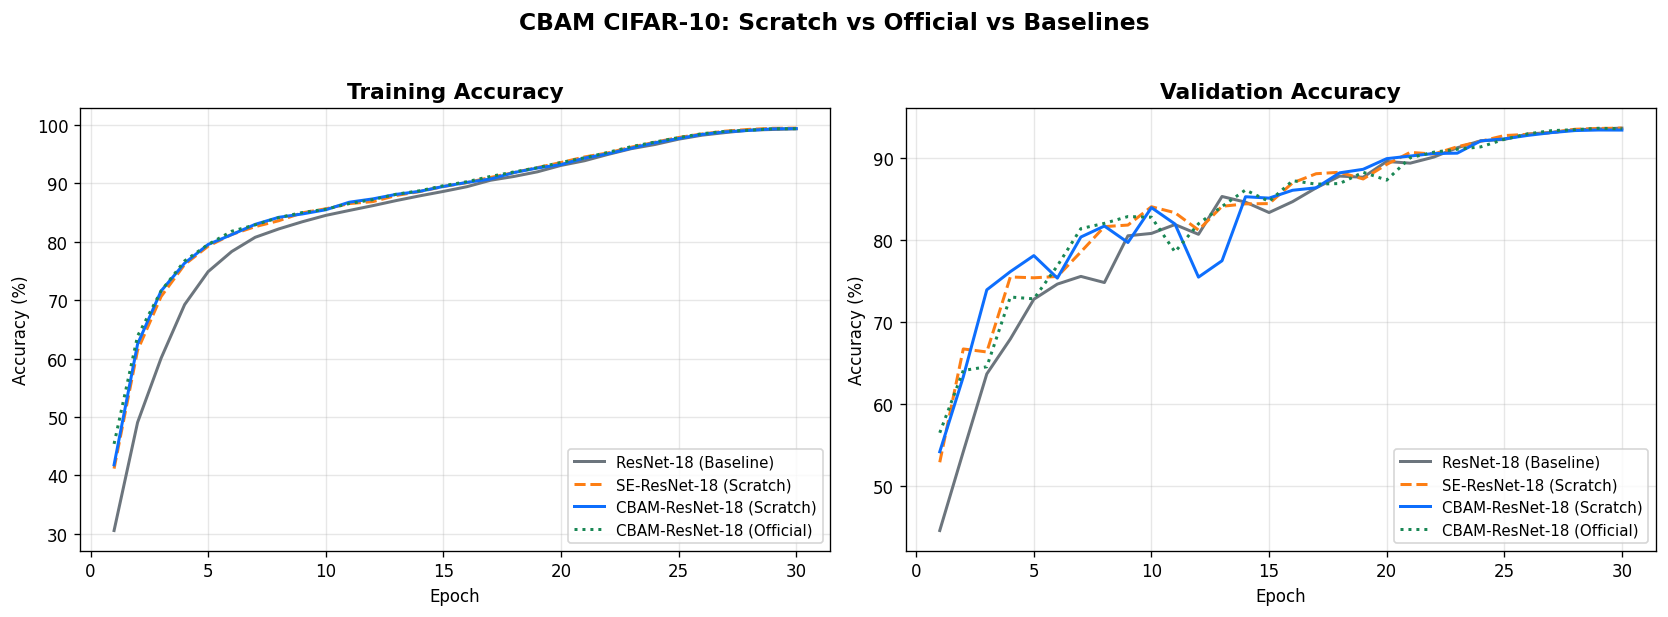

Saved accuracy_curves.png


In [15]:
# ── Accuracy curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Baseline': '#6c757d', 'SE': '#fd7e14',
          'CBAM_scratch': '#0d6efd', 'CBAM_official': '#198754'}
styles = {'Baseline': '-', 'SE': '--', 'CBAM_scratch': '-', 'CBAM_official': ':'}

for k, name in labels.items():
    h = results[k]['history']
    epochs_range = range(1, len(h['val_acc']) + 1)
    axes[0].plot(epochs_range, h['train_acc'],
                 color=colors[k], ls=styles[k], label=name, lw=1.8)
    axes[1].plot(epochs_range, h['val_acc'],
                 color=colors[k], ls=styles[k], label=name, lw=1.8)

for ax, title in zip(axes, ['Training Accuracy', 'Validation Accuracy']):
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('CBAM CIFAR-10: Scratch vs Official vs Baselines',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('accuracy_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved accuracy_curves.png')

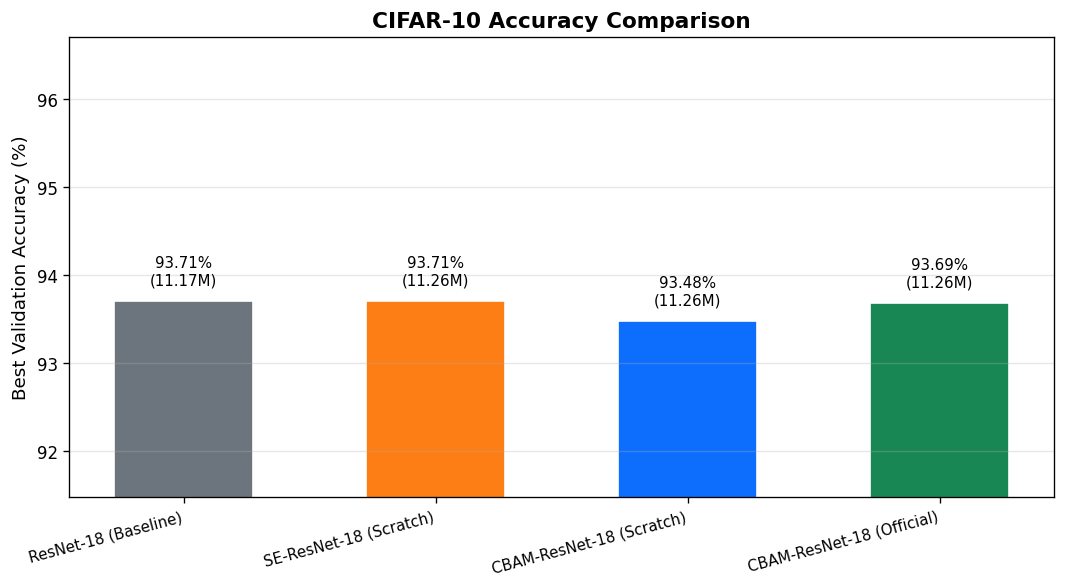

Saved bar_comparison.png


In [16]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

model_names = list(labels.values())
accs   = [results[k]['best_acc']       for k in labels]
params = [param_counts[k] / 1e6        for k in labels]
bar_colors = [colors[k]                for k in labels]

bars = ax.bar(model_names, accs, color=bar_colors, edgecolor='white', width=0.55)
for bar, acc, p in zip(bars, accs, params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{acc:.2f}%\n({p:.2f}M)', ha='center', va='bottom', fontsize=9)

ax.set_ylim(min(accs) - 2, max(accs) + 3)
ax.set_ylabel('Best Validation Accuracy (%)', fontsize=11)
ax.set_title('CIFAR-10 Accuracy Comparison', fontsize=13, fontweight='bold')
plt.xticks(rotation=15, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bar_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved bar_comparison.png')

## 8. Spatial Attention Map Visualisation

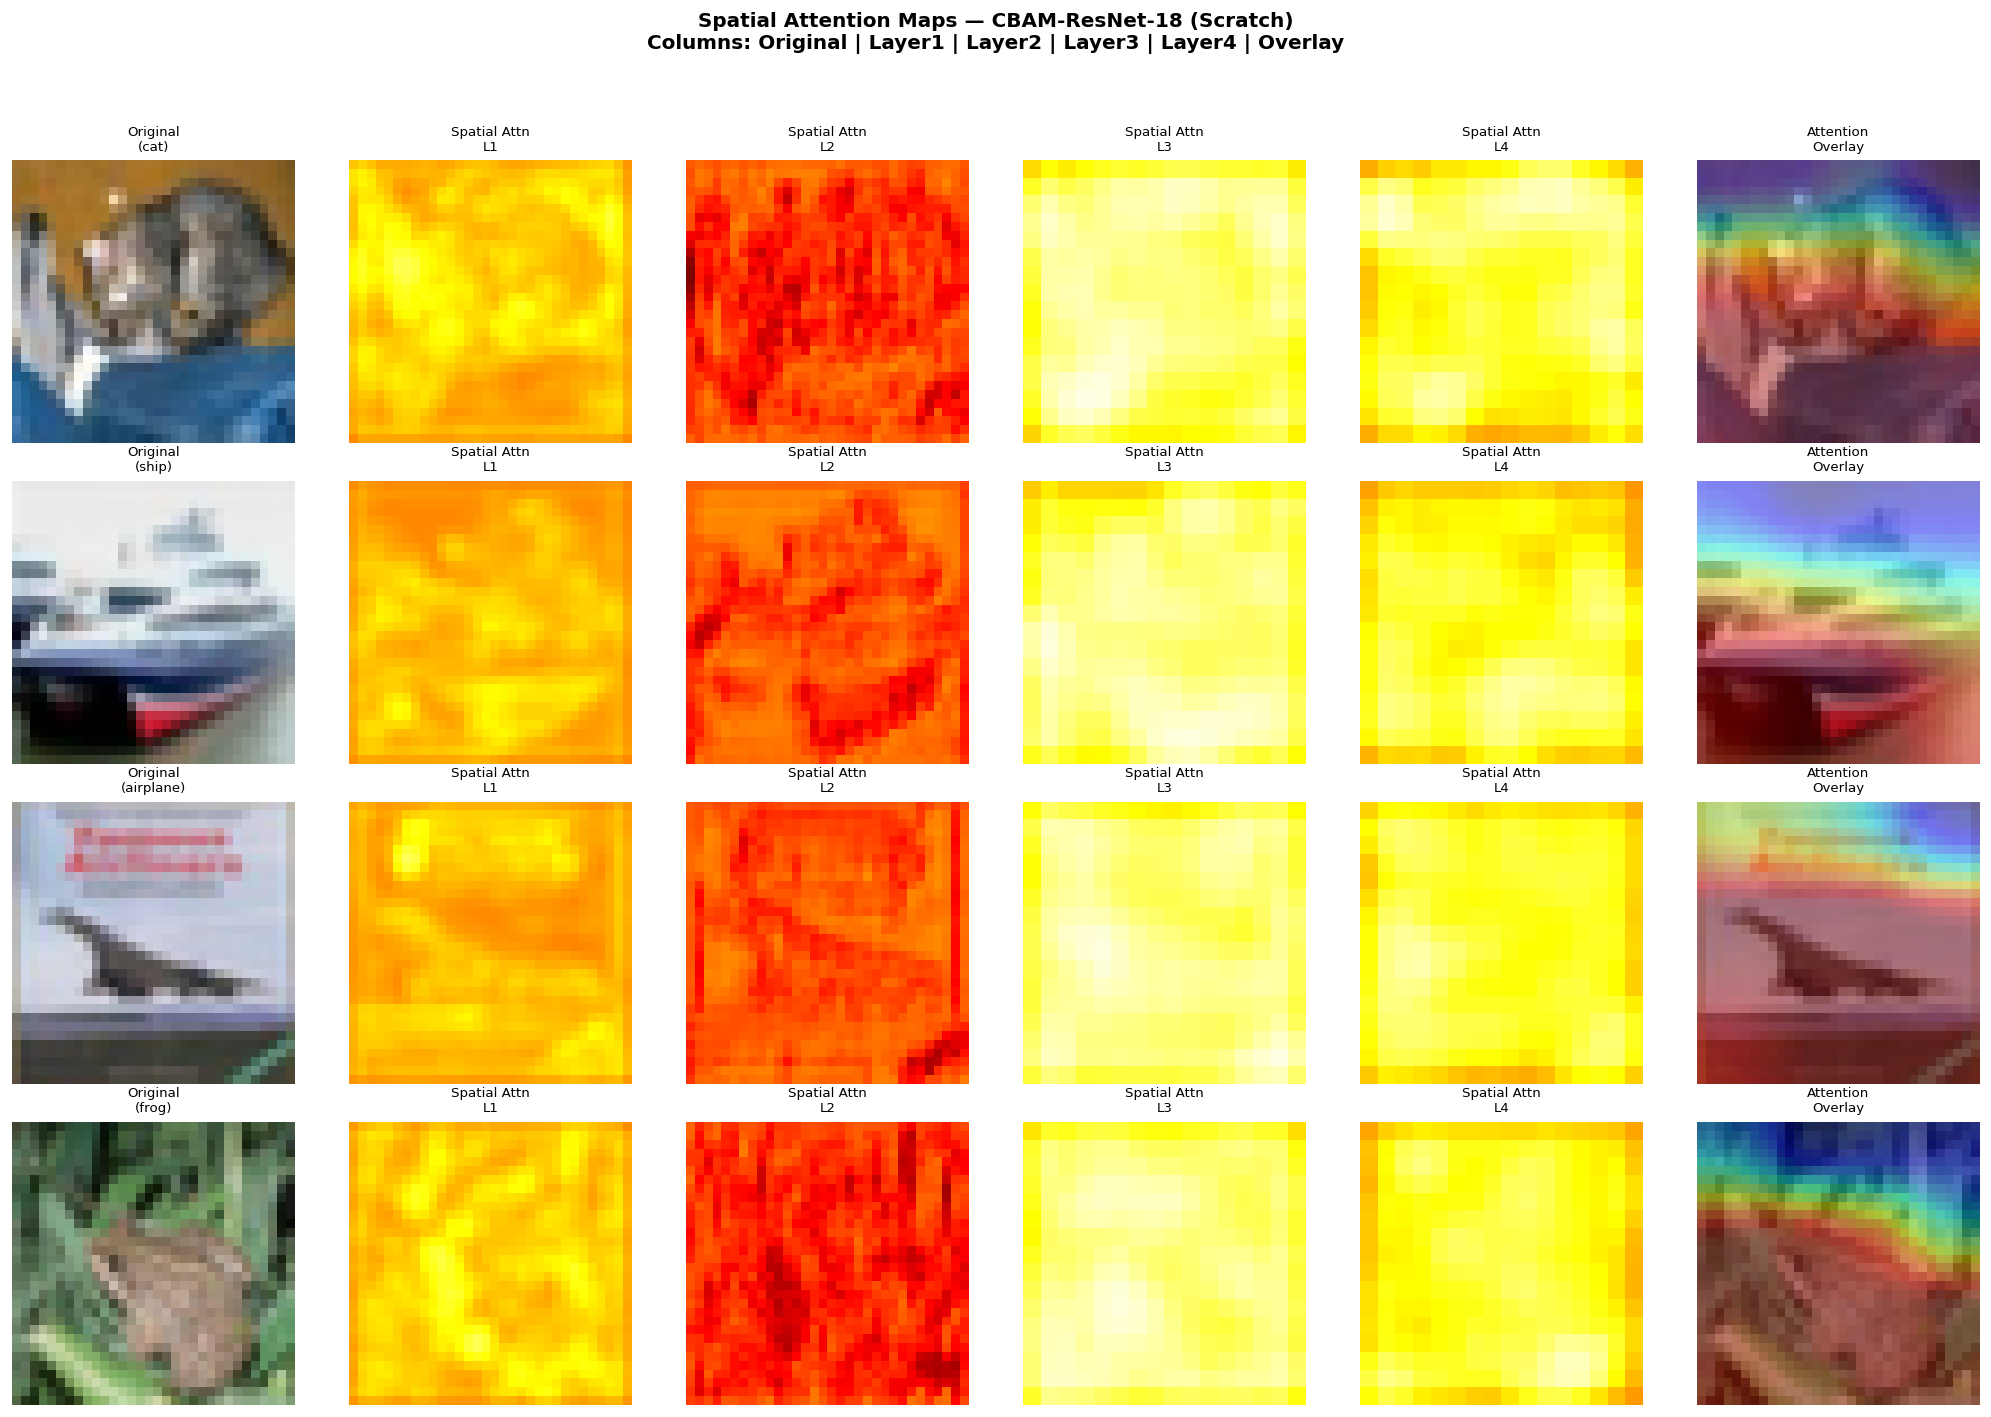

Saved spatial_attention_maps.png


In [17]:
import torchvision.transforms.functional as TF
from torchvision.transforms.functional import to_pil_image


def get_spatial_attention_maps(model, img_tensor):
    """Hook-based extraction of spatial attention maps from all CBAM blocks."""
    maps = []

    def hook_fn(module, inp, out):
        # out is the spatially-attended feature map after SAM
        # We want the SAM's attention map (sigmoid output)
        x = inp[0]
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        concat = torch.cat([avg_out, max_out], dim=1)
        attn = module.sigmoid(module.conv(concat)).squeeze().detach().cpu().numpy()
        maps.append(attn)

    hooks = []
    for module in model.modules():
        if isinstance(module, SpatialAttention):
            hooks.append(module.register_forward_hook(hook_fn))

    model.eval()
    with torch.no_grad():
        model(img_tensor.unsqueeze(0).to(DEVICE))

    for h in hooks:
        h.remove()
    return maps


# Unnormalise for display
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)


def unnorm(t):
    return (t * std + mean).clamp(0, 1)


# Pick 4 images from different classes for a nice visual
sample_indices = []
seen_classes = set()
for idx in range(len(test_dataset)):
    _, label = test_dataset[idx]
    if label not in seen_classes:
        sample_indices.append(idx)
        seen_classes.add(label)
    if len(sample_indices) == 4:
        break

fig, axes = plt.subplots(4, 6, figsize=(17, 12))
fig.suptitle('Spatial Attention Maps — CBAM-ResNet-18 (Scratch)\n'
             'Columns: Original | Layer1 | Layer2 | Layer3 | Layer4 | Overlay',
             fontsize=12, fontweight='bold')

for row, idx in enumerate(sample_indices):
    img_t, label = test_dataset[idx]
    maps = get_spatial_attention_maps(model_cbam, img_t)
    img_display = unnorm(img_t).permute(1, 2, 0).numpy()

    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f'Original\n({CLASSES[label]})', fontsize=8)
    axes[row, 0].axis('off')

    for col, (m, layer_name) in enumerate(zip(maps[:4],
                                              ['L1', 'L2', 'L3', 'L4'])):
        axes[row, col + 1].imshow(m, cmap='hot', vmin=0, vmax=1)
        axes[row, col + 1].set_title(f'Spatial Attn\n{layer_name}', fontsize=8)
        axes[row, col + 1].axis('off')

    # Overlay last layer attention on image
    last_map = maps[-1] if maps else np.ones((4, 4))
    last_resized = np.array(
        to_pil_image(torch.tensor(last_map).unsqueeze(0)).resize((32, 32)))
    axes[row, 5].imshow(img_display)
    axes[row, 5].imshow(last_resized, cmap='jet', alpha=0.45)
    axes[row, 5].set_title('Attention\nOverlay', fontsize=8)
    axes[row, 5].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('spatial_attention_maps.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved spatial_attention_maps.png')

## 9. Final Summary

In [18]:
print('\n' + '='*72)
print('  FINAL RESULTS SUMMARY — CIFAR-10')
print('='*72)
print(f'{"Model":<32} {"Params (M)":>10} {"Best Val Acc":>14} {"Delta vs Base":>14}')
print('-'*72)

base_acc = results['Baseline']['best_acc']
for k, name in labels.items():
    p   = param_counts[k] / 1e6
    acc = results[k]['best_acc']
    d   = acc - base_acc
    delta_str = f'+{d:.2f}%' if d >= 0 else f'{d:.2f}%'
    base_marker = ' (baseline)' if k == 'Baseline' else ''
    print(f'{name:<32} {p:>10.3f} {acc:>13.2f}% {delta_str:>14}{base_marker}')

print('='*72)
print()

scratch  = results['CBAM_scratch']['best_acc']
official = results['CBAM_official']['best_acc']
gap      = abs(scratch - official)
print(f'Scratch vs Official CBAM gap: {gap:.2f}%  '
      f'({"scratch higher" if scratch > official else "official higher"})')
print()
print('Files saved:')
for f in ['accuracy_curves.png', 'bar_comparison.png', 'spatial_attention_maps.png']:
    print(f'  • {f}')


  FINAL RESULTS SUMMARY — CIFAR-10
Model                            Params (M)   Best Val Acc  Delta vs Base
------------------------------------------------------------------------
ResNet-18 (Baseline)                 11.174         93.71%         +0.00% (baseline)
SE-ResNet-18 (Scratch)               11.261         93.71%         +0.00%
CBAM-ResNet-18 (Scratch)             11.261         93.48%         -0.23%
CBAM-ResNet-18 (Official)            11.264         93.69%         -0.02%

Scratch vs Official CBAM gap: 0.21%  (official higher)

Files saved:
  • accuracy_curves.png
  • bar_comparison.png
  • spatial_attention_maps.png
